# SSC0964 — Introdução à Computação no Mercado Financeiro
## Trabalho 1 — Factor Investing: 4 Modelos de Portfólios Multifatores

**1º Semestre 2026 — Prof. Denis Fernando Wolf**

**Autores:**
- Felipe Corerato — NUSP 14569800
- Ana Lívia de Magalhães Garbin — NUSP 14557394


In [2]:
# -*- coding: utf-8 -*-
"""
SSC0964 - Introdução à Computação no Mercado Financeiro
1º Semestre 2026 - Prof. Denis Fernando Wolf

Trabalho 1 - Factor Investing: 4 Modelos de Portfólios Multifatores
"""

# ============================================================
# INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
# %pip install statsmodels python-dateutil pandas numpy matplotlib

import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# CONFIGURAÇÕES GLOBAIS
# ============================================================

start = '1/2002'
end   = '12/2023'

# Custo de transação por rebalanceamento mensal
COST_TRANS = 0.0006

# Dicionário de direção de ranking por fator
# False = maior valor é melhor (ex: ROIC alto é bom)
# True  = menor valor é melhor (ex: EV_EBIT baixo é barato)
ASCENDING_DIC = {
    'ROIC':      False,
    'ROE':       False,
    'EV_EBIT':   True,
    'EBIT_DIVLIQ': False,
    'PVP':       True,
    'Mom12':     False,
    'Mom6':      False,
    'Volat12':   True,
    'Volat6':    True,
    'MTUM6':     False,
    'MTUM12':    False,
}

In [4]:
# ============================================================
# CARREGAMENTO DOS DADOS
# ============================================================

print("=" * 60)
print("Carregando dados...")
print("=" * 60)

dados = pd.read_csv('v5-DB-Acoes.csv', index_col=0)
indices_acc = pd.read_csv('v5-DB-Indices.csv')
indices_acc.set_index('Data', inplace=True)
indices = indices_acc.pct_change(fill_method=None)

print(f"Dados carregados: {dados.shape[0]} registros, {dados.shape[1]} colunas")
print(f"Período do backtest: {start} a {end}\n")

Carregando dados...
Dados carregados: 216128 registros, 18 colunas
Período do backtest: 1/2002 a 12/2023



In [5]:
# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def calc_dif_dates(start, end):
    """Calcula diferença em anos entre duas datas no formato m/yyyy."""
    data_dif = relativedelta(
        datetime.strptime(end, '%m/%Y'),
        datetime.strptime(start, '%m/%Y')
    )
    return data_dif.years + data_dif.months / 12


def calcular_metricas(Port, nome_modelo):
    """
    Calcula e imprime todas as métricas exigidas pelo trabalho:
    retorno anualizado, volatilidade anualizada, retorno/volatilidade,
    drawdown, alpha e beta.
    """
    anos = calc_dif_dates(start, end)

    ret_acc   = Port['Ret_acc'].iloc[-1] * 100
    vol_aa    = Port['Ret'].std() * (12 ** 0.5) * 100
    ret_aa    = (pow(ret_acc / 100 + 1, 1 / anos) - 1) * 100
    ret_vol   = ret_aa / vol_aa if vol_aa != 0 else np.nan
    drawdown  = Port['drawdown'].min() * 100

    ref_ret_acc = Port['Ref_acc'].iloc[-1] * 100
    ref_vol_aa  = Port['Ref'].std() * (12 ** 0.5) * 100
    ref_ret_aa  = (pow(ref_ret_acc / 100 + 1, 1 / anos) - 1) * 100

    model_ols = sm.OLS(
        Port['Ret'].to_list(),
        sm.add_constant(Port['Ref'].to_list()),
        missing='drop'
    ).fit()
    alpha = model_ols.params[0] * 12 * 100
    beta  = model_ols.params[1]
    pval_alpha = model_ols.pvalues[0]
    pval_beta  = model_ols.pvalues[1]

    print(f"\n{'=' * 60}")
    print(f"  {nome_modelo}")
    print(f"{'=' * 60}")
    print(f"  Retorno Acumulado:          {ret_acc:.2f}%")
    print(f"  Retorno Anualizado:         {ret_aa:.2f}%")
    print(f"  Volatilidade Anualizada:    {vol_aa:.2f}%")
    print(f"  Retorno / Volatilidade:     {ret_vol:.3f}")
    print(f"  Drawdown Máximo:            {drawdown:.2f}%")
    print(f"  Alpha (aa):                 {alpha:.2f}%  (p-value: {pval_alpha:.3f})")
    print(f"  Beta:                       {beta:.2f}   (p-value: {pval_beta:.3f})")
    print(f"  --- Referência (IBOV) ---")
    print(f"  Ret. Anual Ref.:            {ref_ret_aa:.2f}%")
    print(f"  Vol. Anual Ref.:            {ref_vol_aa:.2f}%")

    return {
        'nome': nome_modelo,
        'ret_acc': ret_acc,
        'ret_aa': ret_aa,
        'vol_aa': vol_aa,
        'ret_vol': ret_vol,
        'drawdown': drawdown,
        'alpha': alpha,
        'beta': beta,
        'pval_alpha': pval_alpha,
    }


def plotar_modelo(Port, nome_modelo, cor='steelblue'):
    """
    Gera os 4 gráficos exigidos pelo trabalho para um dado modelo:
    1. Retorno acumulado
    2. Média móvel de 60 meses
    3. Volatilidade anualizada (janela 12m)
    4. Drawdown
    """
    Port_acc = pd.DataFrame({'Portfólio': Port['Ret_acc'],
                             'IBOV':      Port['Ref_acc']})
    Port_ret = pd.DataFrame({'Portfólio': Port['Ret'],
                             'IBOV':      Port['Ref']})

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(nome_modelo, fontsize=14, fontweight='bold', y=1.01)

    # --- 1. Retorno acumulado ---
    ax = axes[0, 0]
    (Port_acc * 100).plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Retorno Acumulado (%)')
    ax.set_xlabel('')
    ax.legend()
    ax.grid(True)

    # --- 2. Média móvel 60 meses ---
    ax = axes[0, 1]
    med_movel = 60
    Port_mm = ((1 + Port_acc) / (1 + Port_acc.shift(med_movel)) - 1) * 100
    Port_mm.iloc[24:].plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Média Móvel 60 Meses (%)')
    ax.set_xlabel('')
    ax.legend()
    ax.grid(True)

    # --- 3. Volatilidade anualizada (janela 12m) ---
    ax = axes[1, 0]
    Port_vol = (1 + Port_ret).rolling(12).std() * (12 ** 0.5) * 100
    Port_vol.plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Volatilidade Anualizada - janela 12m (%)')
    ax.set_xlabel('')
    ax.legend()
    ax.grid(True)

    # --- 4. Drawdown ---
    ax = axes[1, 1]
    Port_acc_max  = Port_acc.cummax()
    Port_drawdown = (((1 + Port_acc) / (1 + Port_acc_max)) - 1) * 100
    Port_drawdown.plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Drawdown (%)')
    ax.set_xlabel('')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [6]:
# ============================================================
# FUNÇÃO CORE: CONSTRUÇÃO DO PORTFÓLIO MULTIFATOR (SOMA DE RANKS)
# ============================================================

def create_port_multifator(fatores, filtro_fim, dados, referencia, nome='Portfólio'):
    """
    Constrói um portfólio multifator usando soma de rankings.

    Parâmetros
    ----------
    fatores    : lista de str — fatores a combinar (mínimo 2)
    filtro_fim : int — número de ações selecionadas (top N do ranking combinado)
    dados      : DataFrame — base de ações com colunas de fatores
    referencia : Series — retornos mensais do benchmark
    nome       : str — nome descritivo do modelo

    Retorna
    -------
    DataFrame com colunas: Ret, Ret_acc, drawdown, Ref, Ref_acc
    """
    list_date = []
    list_ret  = []

    for dt in pd.date_range(start=start, end=end, freq='ME').strftime('%b-%Y'):

        # Filtra ações do IBX com retorno disponível no período
        cart = dados.loc[
            (dados['Data'] == dt) &
            (dados['IBX'] > 0) &
            (dados['Retorno'].isnull() == False)
        ].copy()

        if cart.empty:
            list_date.append(dt)
            list_ret.append(np.nan)
            continue

        # Rankeia cada fator e soma os rankings
        rank_sum = pd.Series(0.0, index=cart.index)
        for fator in fatores:
            if fator in cart.columns:
                cart[f'rank_{fator}'] = cart[fator].rank(ascending=ASCENDING_DIC[fator])
                rank_sum += cart[f'rank_{fator}']

        cart['rank_final'] = rank_sum.rank(ascending=True)

        # Seleciona as top N ações (menor rank_final = melhor combinação)
        selecao = cart.loc[cart['rank_final'] <= filtro_fim]
        ret = selecao['Retorno'].mean() - COST_TRANS

        list_date.append(dt)
        list_ret.append(ret)

    Port = pd.DataFrame({'Data': list_date, 'Ret': list_ret})
    Port.set_index('Data', inplace=True)

    Port['Ret_acc'] = (1 + Port['Ret']).cumprod() - 1
    Port['acc_max'] = Port['Ret_acc'].cummax()
    Port['drawdown'] = ((1 + Port['Ret_acc']) / (1 + Port['acc_max'])) - 1

    Port['Ref']     = referencia
    Port['Ref_acc'] = (1 + Port['Ref']).cumprod() - 1

    return Port.copy()


CONSTRUINDO MODELO 1 — MAIOR RETORNO
Fatores: Mom12 + ROIC

  Modelo 1 — Maior Retorno (Mom12 + ROIC)
  Retorno Acumulado:          5611.65%
  Retorno Anualizado:         20.27%
  Volatilidade Anualizada:    20.62%
  Retorno / Volatilidade:     0.983
  Drawdown Máximo:            -47.83%
  Alpha (aa):                 11.53%  (p-value: 0.000)
  Beta:                       0.71   (p-value: 0.000)
  --- Referência (IBOV) ---
  Ret. Anual Ref.:            10.75%
  Vol. Anual Ref.:            23.66%


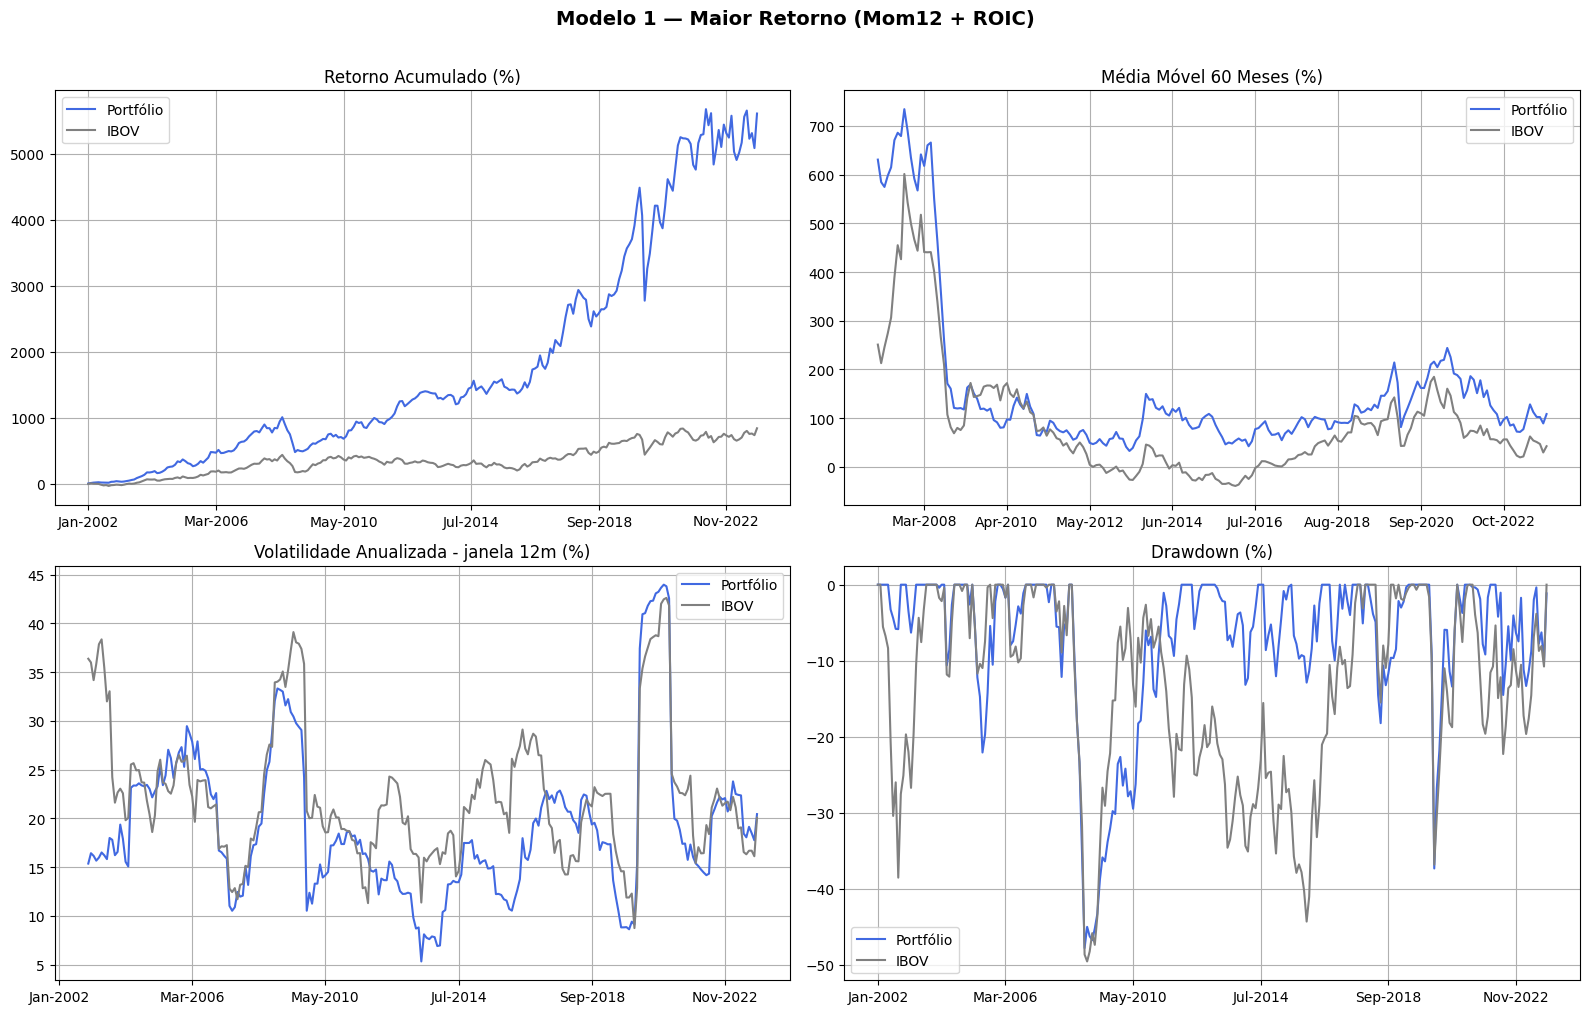

In [7]:
# ============================================================
# MODELO 1 — MAIOR RETORNO
# Objetivo: maximizar retorno absoluto.
# Fatores: Mom12 (momentum 12 meses) + ROIC (qualidade/retorno sobre capital)
#
# Lógica de seleção:
#   - Mom12: ações com maior retorno nos últimos 12 meses tendem a
#     continuar performando bem (fator momentum, Jegadeesh & Titman 1993).
#   - ROIC: empresas com alto retorno sobre capital investido são
#     fundamentalmente mais rentáveis e tendem a gerar mais retorno.
#   - A combinação premia ações que já mostram força de preço E
#     possuem qualidade fundamentalista — buscando o maior retorno possível.
# ============================================================

print("\n" + "=" * 60)
print("CONSTRUINDO MODELO 1 — MAIOR RETORNO")
print("Fatores: Mom12 + ROIC")
print("=" * 60)

Port1 = create_port_multifator(
    fatores=['Mom12', 'ROIC'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['IBOV'],
    nome='Modelo 1'
)

metricas1 = calcular_metricas(Port1, 'Modelo 1 — Maior Retorno (Mom12 + ROIC)')
plotar_modelo(Port1, 'Modelo 1 — Maior Retorno (Mom12 + ROIC)', cor='royalblue')


CONSTRUINDO MODELO 2 — MAIOR RETORNO/VOLATILIDADE
Fatores: EBIT_DIVLIQ + EV_EBIT

  Modelo 2 — Maior Retorno/Volatilidade (EBIT_DIVLIQ + EV_EBIT)
  Retorno Acumulado:          855.54%
  Retorno Anualizado:         10.85%
  Volatilidade Anualizada:    20.91%
  Retorno / Volatilidade:     0.519
  Drawdown Máximo:            -39.93%
  Alpha (aa):                 7.45%  (p-value: 0.002)
  Beta:                       0.80   (p-value: 0.000)
  --- Referência (IBOV) ---
  Ret. Anual Ref.:            10.75%
  Vol. Anual Ref.:            23.66%


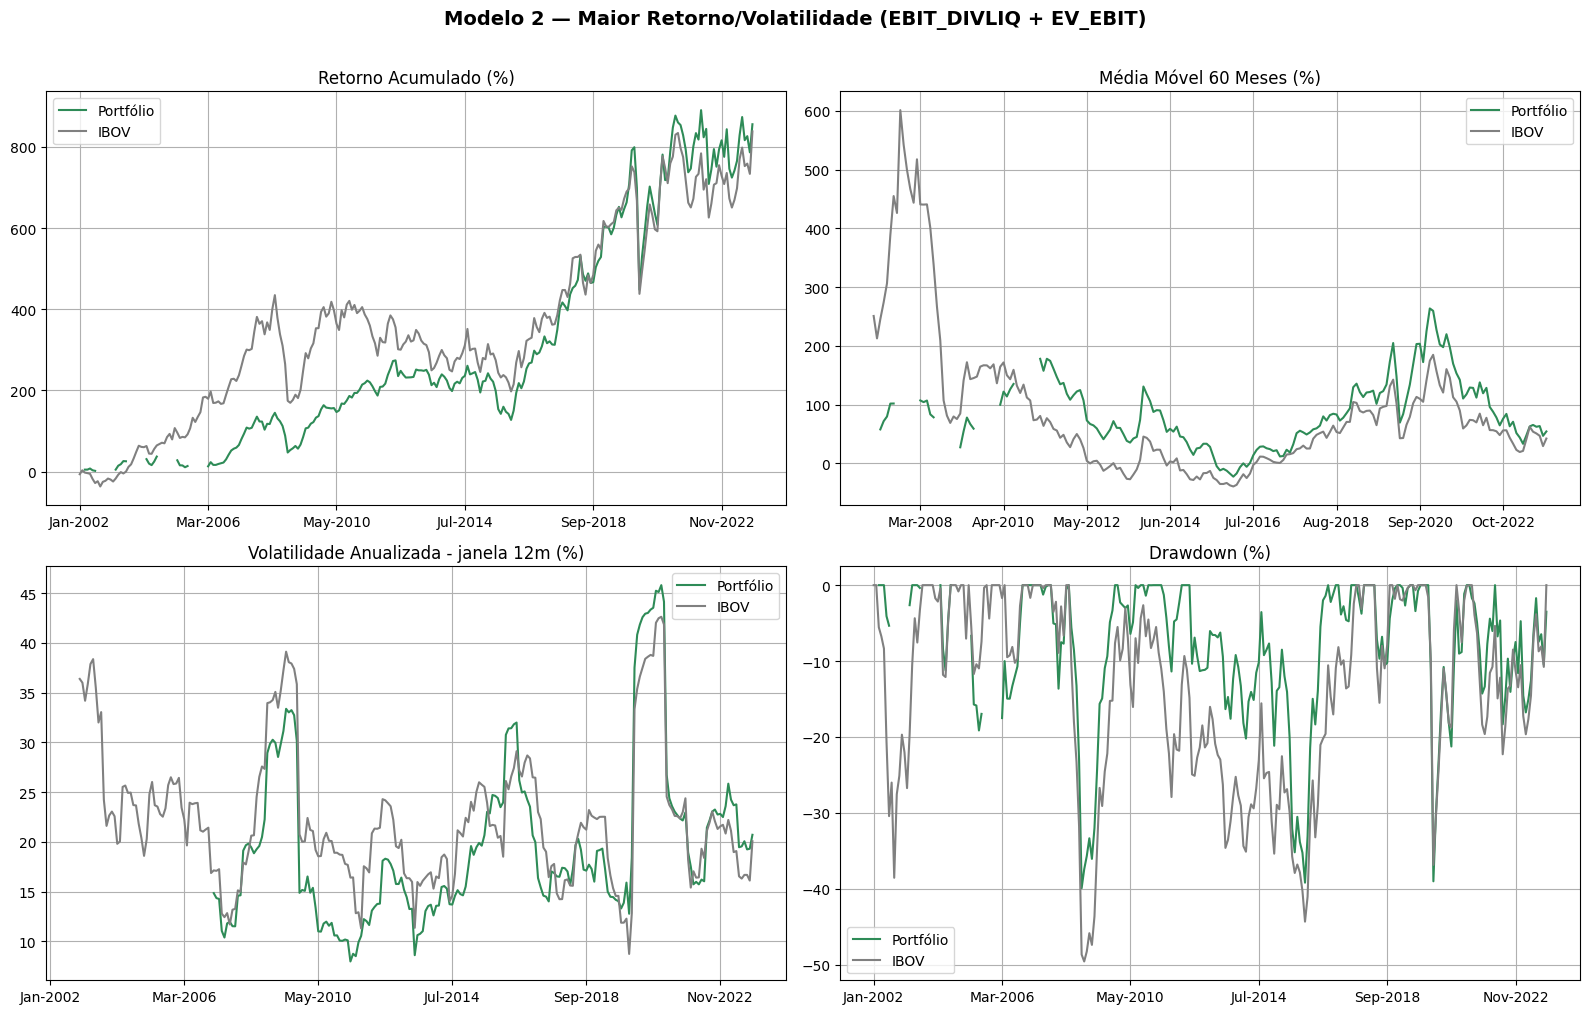

In [8]:
# ============================================================
# MODELO 2 — MAIOR RELAÇÃO RETORNO / VOLATILIDADE (Sharpe-like)
# Objetivo: maximizar retorno por unidade de risco.
# Fatores: EBIT_DIVLIQ (qualidade/solidez financeira) + EV_EBIT (valor)
#
# Lógica de seleção:
#   - EBIT_DIVLIQ: mede a capacidade da empresa de pagar sua dívida com
#     o lucro operacional. Empresas sólidas financeiramente têm retornos
#     mais estáveis e consistentes — menor volatilidade.
#   - EV_EBIT: empresas baratas em relação ao lucro operacional (fator
#     valor) tendem a ter bom retorno com menor risco de "pagar caro".
#   - A combinação visa encontrar empresas lucrativas, financeiramente
#     saudáveis e negociadas a preço justo, maximizando a relação risco/retorno.
# ============================================================

print("\n" + "=" * 60)
print("CONSTRUINDO MODELO 2 — MAIOR RETORNO/VOLATILIDADE")
print("Fatores: EBIT_DIVLIQ + EV_EBIT")
print("=" * 60)

Port2 = create_port_multifator(
    fatores=['EBIT_DIVLIQ', 'EV_EBIT'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['IBOV'],
    nome='Modelo 2'
)

metricas2 = calcular_metricas(Port2, 'Modelo 2 — Maior Retorno/Volatilidade (EBIT_DIVLIQ + EV_EBIT)')
plotar_modelo(Port2, 'Modelo 2 — Maior Retorno/Volatilidade (EBIT_DIVLIQ + EV_EBIT)', cor='seagreen')


CONSTRUINDO MODELO 3 — MAIOR ALPHA
Fatores: ROE + Mom6 + EV_EBIT

  Modelo 3 — Maior Alpha (ROE + Mom6 + EV_EBIT)
  Retorno Acumulado:          1043.93%
  Retorno Anualizado:         11.76%
  Volatilidade Anualizada:    19.84%
  Retorno / Volatilidade:     0.593
  Drawdown Máximo:            -44.63%
  Alpha (aa):                 8.56%  (p-value: 0.000)
  Beta:                       0.75   (p-value: 0.000)
  --- Referência (IBOV) ---
  Ret. Anual Ref.:            10.75%
  Vol. Anual Ref.:            23.66%


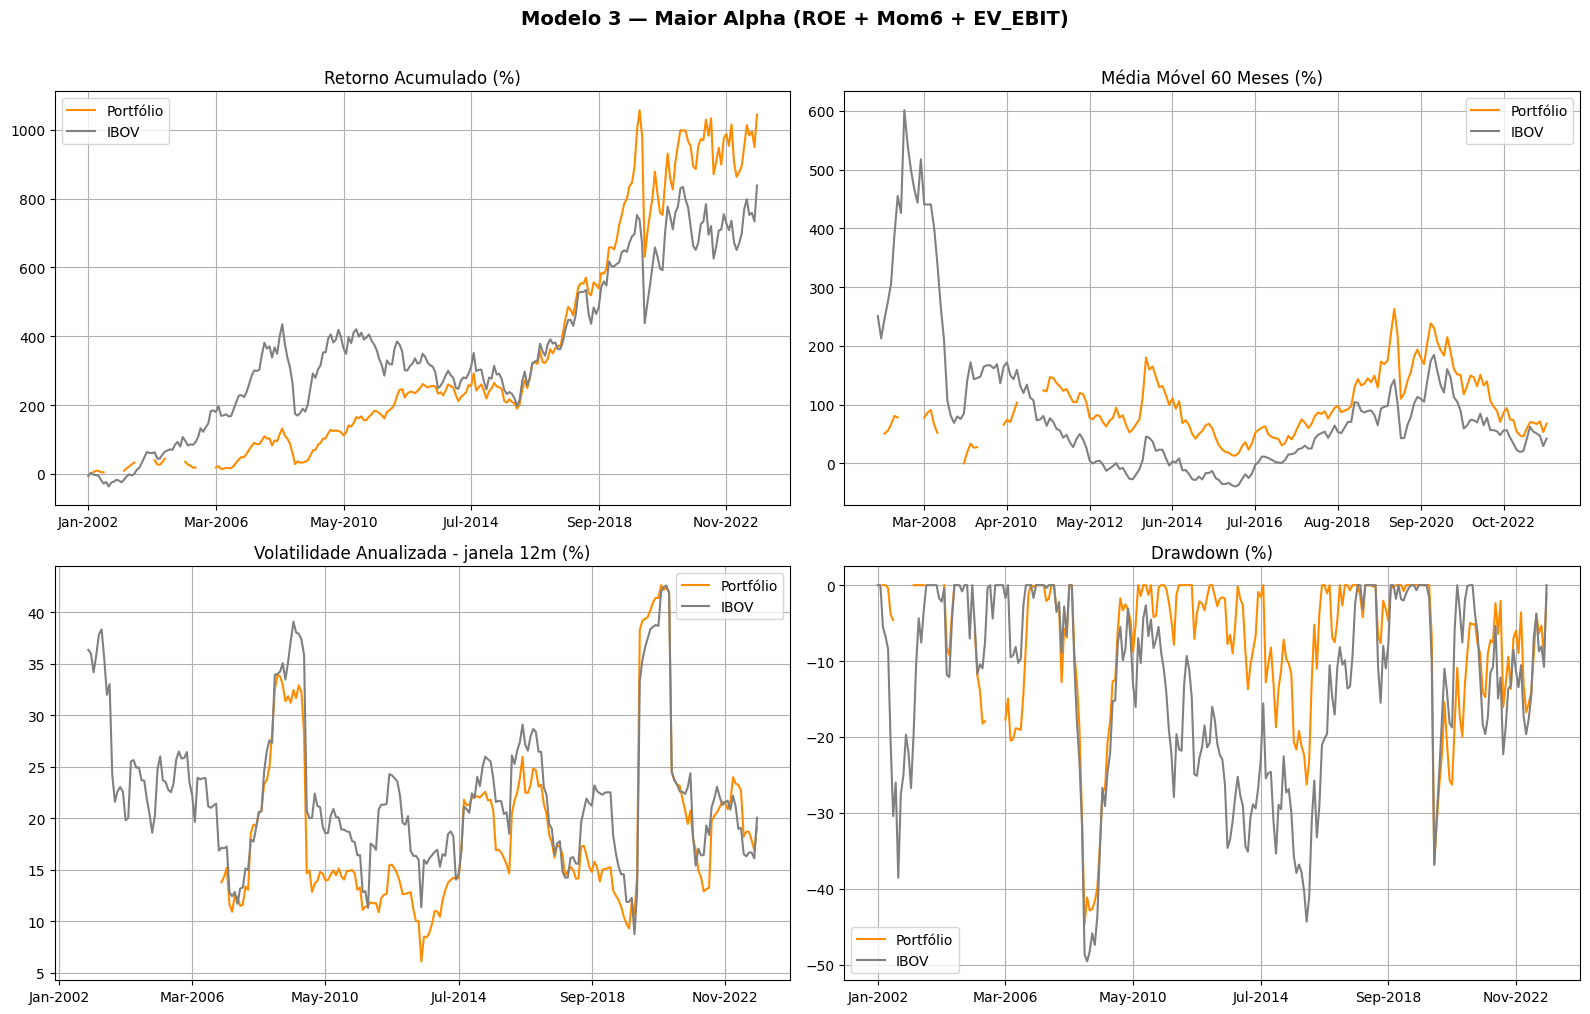

In [9]:
# ============================================================
# MODELO 3 — MAIOR ALPHA
# Objetivo: maximizar retorno acima do mercado (alpha).
# Fatores: ROE (qualidade) + Mom6 (momentum curto) + EV_EBIT (valor)
#
# Lógica de seleção:
#   - ROE: empresas com alto retorno sobre patrimônio são mais
#     eficientes e tendem a superar o mercado sistematicamente.
#   - Mom6: momentum de curto prazo captura movimentos recentes de
#     mercado e pode antecipar alpha de curto prazo.
#   - EV_EBIT: o fator valor ajuda a evitar overpaying, contribuindo
#     para um alpha mais robusto e consistente.
#   - Três fatores de categorias distintas (qualidade + momentum +
#     valor) aumentam a diversificação do modelo e a chance de alpha
#     persistente, independentemente do ciclo de mercado.
# ============================================================

print("\n" + "=" * 60)
print("CONSTRUINDO MODELO 3 — MAIOR ALPHA")
print("Fatores: ROE + Mom6 + EV_EBIT")
print("=" * 60)

Port3 = create_port_multifator(
    fatores=['ROE', 'Mom6', 'EV_EBIT'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['IBOV'],
    nome='Modelo 3'
)

metricas3 = calcular_metricas(Port3, 'Modelo 3 — Maior Alpha (ROE + Mom6 + EV_EBIT)')
plotar_modelo(Port3, 'Modelo 3 — Maior Alpha (ROE + Mom6 + EV_EBIT)', cor='darkorange')


CONSTRUINDO MODELO 4 — MENOR VOLATILIDADE
Fatores: Volat12 + EBIT_DIVLIQ

  Modelo 4 — Menor Volatilidade (Volat12 + EBIT_DIVLIQ)
  Retorno Acumulado:          2999.67%
  Retorno Anualizado:         16.96%
  Volatilidade Anualizada:    16.96%
  Retorno / Volatilidade:     1.000
  Drawdown Máximo:            -32.81%
  Alpha (aa):                 9.23%  (p-value: 0.000)
  Beta:                       0.61   (p-value: 0.000)
  --- Referência (IBOV) ---
  Ret. Anual Ref.:            10.75%
  Vol. Anual Ref.:            23.66%


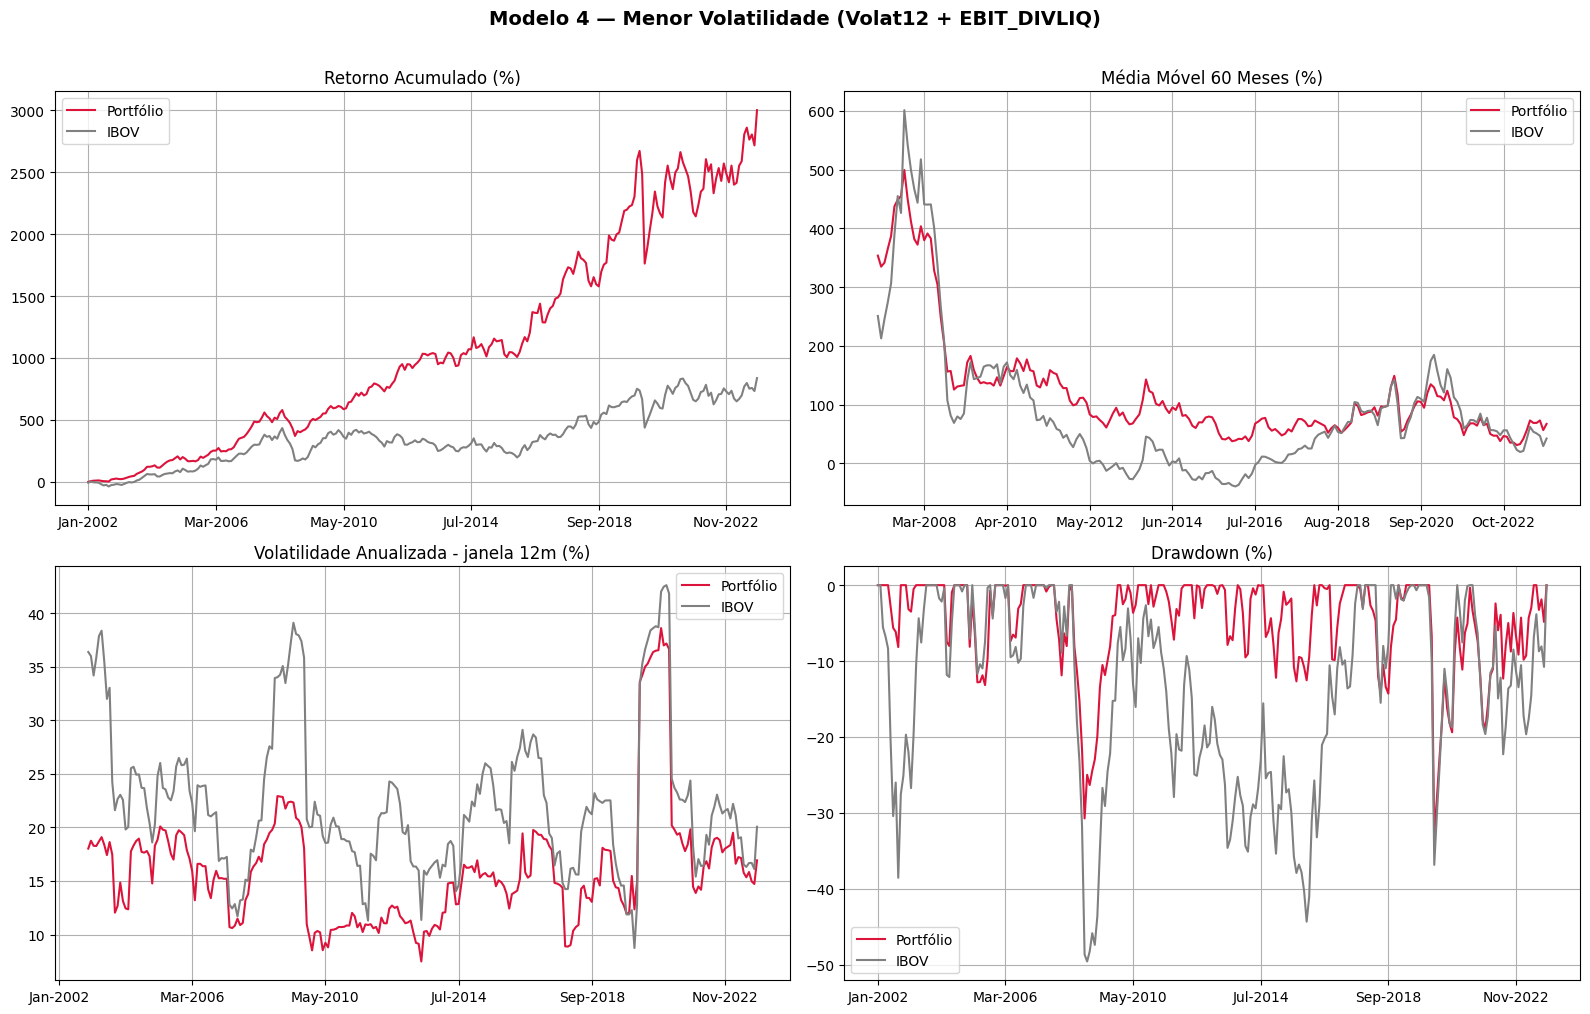

In [10]:
# ============================================================
# MODELO 4 — MENOR VOLATILIDADE
# Objetivo: minimizar o risco do portfólio.
# Fatores: Volat12 (baixa volatilidade 12m) + EBIT_DIVLIQ (solidez financeira)
#
# Lógica de seleção:
#   - Volat12: o fator de baixa volatilidade é amplamente documentado
#     na literatura (anomalia low-vol, França 2017): ações menos
#     voláteis tendem a entregar melhor risco/retorno no longo prazo.
#   - EBIT_DIVLIQ: empresas com baixa alavancagem e alto lucro
#     operacional em relação à dívida são mais resilientes em crises,
#     o que naturalmente reduz a volatilidade do portfólio.
#   - A combinação dupla de filtros — preço e fundamento — resulta
#     em um portfólio defensivo, com menor drawdown e oscilações.
# ============================================================

print("\n" + "=" * 60)
print("CONSTRUINDO MODELO 4 — MENOR VOLATILIDADE")
print("Fatores: Volat12 + EBIT_DIVLIQ")
print("=" * 60)

Port4 = create_port_multifator(
    fatores=['Volat12', 'EBIT_DIVLIQ'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['IBOV'],
    nome='Modelo 4'
)

metricas4 = calcular_metricas(Port4, 'Modelo 4 — Menor Volatilidade (Volat12 + EBIT_DIVLIQ)')
plotar_modelo(Port4, 'Modelo 4 — Menor Volatilidade (Volat12 + EBIT_DIVLIQ)', cor='crimson')


COMPARATIVO FINAL DOS 4 MODELOS
                                                               Ret Acc (%)  Ret Aa (%)  Vol Aa (%)  Ret/Vol  Drawdown (%)  Alpha Aa (%)  Beta  p-val α
nome                                                                                                                                                  
Modelo 1 — Maior Retorno (Mom12 + ROIC)                            5611.65       20.27       20.62     0.98        -47.83         11.53  0.71      0.0
Modelo 2 — Maior Retorno/Volatilidade (EBIT_DIVLIQ + EV_EBIT)       855.54       10.85       20.91     0.52        -39.93          7.45  0.80      0.0
Modelo 3 — Maior Alpha (ROE + Mom6 + EV_EBIT)                      1043.93       11.76       19.84     0.59        -44.63          8.56  0.75      0.0
Modelo 4 — Menor Volatilidade (Volat12 + EBIT_DIVLIQ)              2999.67       16.96       16.96     1.00        -32.81          9.23  0.61      0.0


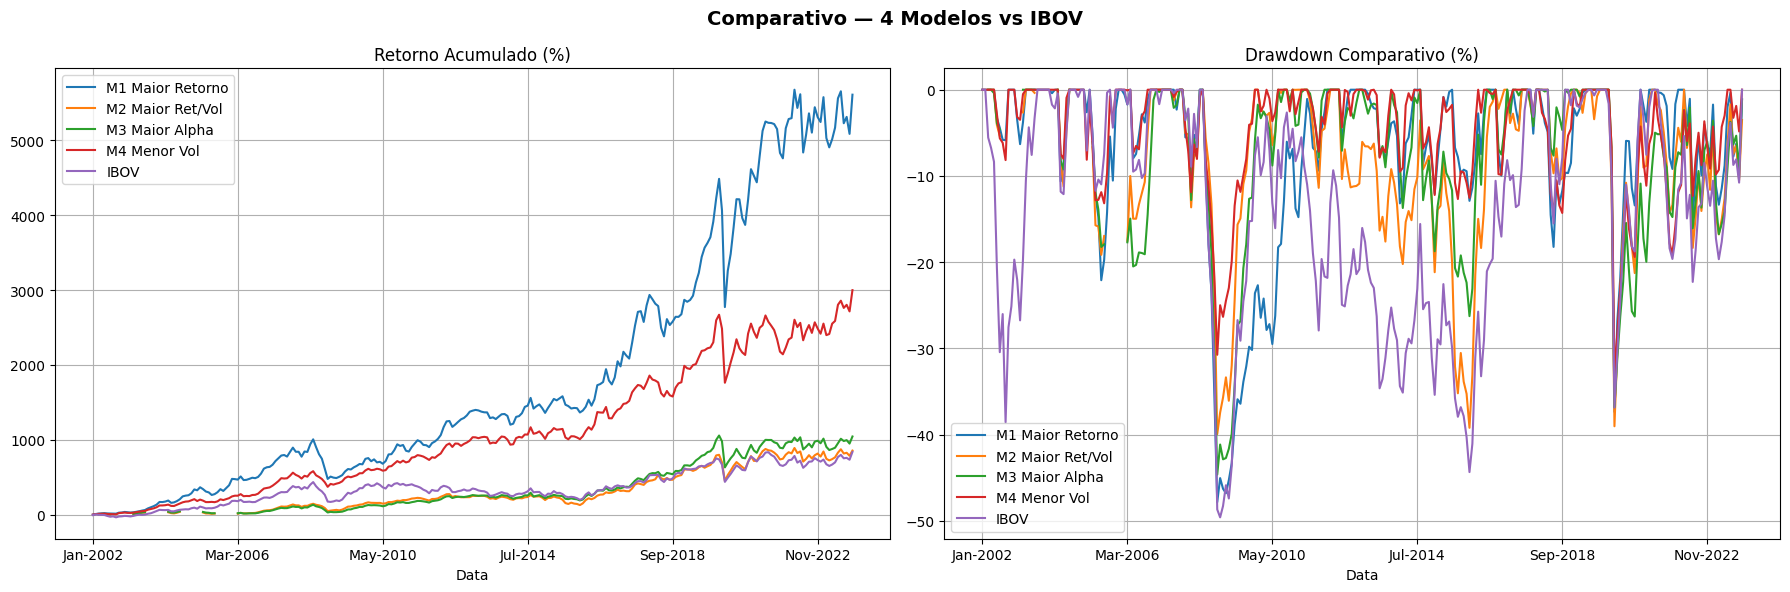


✅ Trabalho 1 — análise concluída!
Os gráficos e métricas acima cobrem todos os requisitos do enunciado.


In [11]:
# ============================================================
# COMPARATIVO FINAL — TODOS OS MODELOS vs IBOV
# ============================================================

print("\n" + "=" * 60)
print("COMPARATIVO FINAL DOS 4 MODELOS")
print("=" * 60)

# Tabela resumo
resumo = pd.DataFrame([metricas1, metricas2, metricas3, metricas4])
resumo = resumo.set_index('nome')
resumo.columns = ['Ret Acc (%)', 'Ret Aa (%)', 'Vol Aa (%)', 'Ret/Vol', 'Drawdown (%)', 'Alpha Aa (%)', 'Beta', 'p-val α']
print(resumo.round(2).to_string())

# Gráfico comparativo — retorno acumulado dos 4 modelos + IBOV
Port_comp = pd.DataFrame({
    'M1 Maior Retorno':    Port1['Ret_acc'],
    'M2 Maior Ret/Vol':    Port2['Ret_acc'],
    'M3 Maior Alpha':      Port3['Ret_acc'],
    'M4 Menor Vol':        Port4['Ret_acc'],
    'IBOV':                Port1['Ref_acc'],
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comparativo — 4 Modelos vs IBOV', fontsize=14, fontweight='bold')

# Retorno acumulado
ax = axes[0]
(Port_comp * 100).plot(ax=ax)
ax.set_title('Retorno Acumulado (%)')
ax.legend()
ax.grid(True)

# Drawdown comparativo
Port_comp_max  = Port_comp.cummax()
Port_comp_ddown = (((1 + Port_comp) / (1 + Port_comp_max)) - 1) * 100
ax = axes[1]
Port_comp_ddown.plot(ax=ax)
ax.set_title('Drawdown Comparativo (%)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()